In [1]:
#importing required libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [2]:
#Dataset path
train_path=r"C:\Users\Cnaan\Downloads\archive (6)\medicine_dataset\train"
validation_path=r"C:\Users\Cnaan\Downloads\archive (6)\medicine_dataset\val"
test_path=r"C:\Users\Cnaan\Downloads\archive (6)\medicine_dataset\test"

In [4]:
#Image Preprocessing:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.3,
    brightness_range=[0.7,1.3],
    horizontal_flip=True,
    shear_range=0.2,
    fill_mode='nearest'
)

validation_datagen= ImageDataGenerator(rescale =1./255)

test_datagen= ImageDataGenerator(rescale=1./255)

In [5]:
#Load images":
train_generator= train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

validation_generator= validation_datagen.flow_from_directory(
    validation_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_generator= test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)



Found 661 images belonging to 2 classes.
Found 453 images belonging to 2 classes.
Found 449 images belonging to 2 classes.


In [6]:
#Check classes
print(train_generator.class_indices)

{'Fake': 0, 'Real': 1}


In [7]:
#Build CNN model
model = Sequential()

model.add(Input(shape=(224,224,3)))

model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))

In [8]:
#Compile Model:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
#Train model
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 734ms/step - accuracy: 0.6430 - loss: 1.5700 - val_accuracy: 0.3996 - val_loss: 0.6881
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 582ms/step - accuracy: 0.7322 - loss: 0.5543 - val_accuracy: 0.7748 - val_loss: 0.5146
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 574ms/step - accuracy: 0.7595 - loss: 0.4888 - val_accuracy: 0.8035 - val_loss: 0.3849
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 581ms/step - accuracy: 0.7897 - loss: 0.4478 - val_accuracy: 0.8609 - val_loss: 0.3791
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 606ms/step - accuracy: 0.7655 - loss: 0.5198 - val_accuracy: 0.8366 - val_loss: 0.4350
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 614ms/step - accuracy: 0.7852 - loss: 0.4547 - val_accuracy: 0.8234 - val_loss: 0.3525
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 598ms/step - accuracy: 0.7988 - loss: 0.4408 - val_accuracy: 0.8631 - val_loss: 0.3688
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 616ms/step - accuracy: 0.8079 - loss: 0.4234 - val_accu

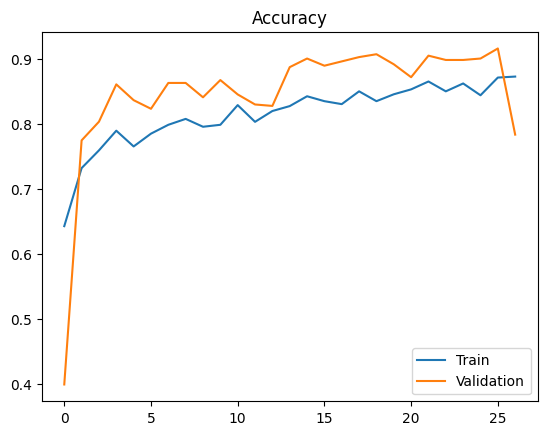

In [11]:
#Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['Train','Validation'])
plt.title("Accuracy")
plt.show()

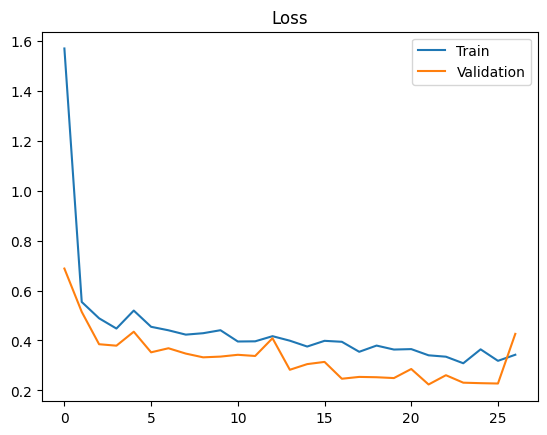

In [12]:
#Loss Graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(['Train','Validation'])
plt.title("Loss")
plt.show()

In [13]:
#Evaluate model
loss,accuracy = model.evaluate(test_generator)
print("Accuracy:",accuracy)

15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 460ms/step - accuracy: 0.8931 - loss: 0.2461
Accuracy: 0.8930957913398743


In [14]:
#save the model
model.save("medicine_model.keras")

In [15]:
#predict a Single image
from tensorflow.keras.preprocessing import image

img = image.load_img(
    r"C:\Users\Cnaan\Downloads\WhatsApp Image 2026-07-06 at 6.27.36 PM.png",
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = img_array/255.0

img_array = np.expand_dims(img_array,axis=0)


prediction = model.predict(img_array)
print(prediction)

if prediction[0][0] > 0.5:
    print("Real Medicine")
else:
    print("Fake Medicine")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step
[[0.41770166]]
Fake Medicine


In [16]:
# import cv2
# from tensorflow.keras.models import load_model

# model=load_model("medicine_model.keras")

# cap=cv2.VideoCapture(0)

# while True:

#     ret,frame=cap.read()

#     img=cv2.resize(frame,(224,224))

#     img=img/255

#     img=np.expand_dims(img,axis=0)

#     pred=model.predict(img)

#     if pred[0][0]>0.5:
#         label="Real"
#     else:
#         label="Fake"

#     cv2.putText(frame,label,(30,40),
#                 cv2.FONT_HERSHEY_SIMPLEX,
#                 1,(0,255,0),2)

#     cv2.imshow("Medicine Detection",frame)

#     if cv2.waitKey(1)==27:
#         break

# cap.release()
# cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms

In [ ]:
#streamlit run app.py